<a href="https://colab.research.google.com/github/RafaelNovais/MasterAI/blob/master/Stress_Predict_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. Load data and pre-process

In [9]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
from sklearn.model_selection import (train_test_split, GroupShuffleSplit, GroupKFold,
                                     StratifiedKFold, GridSearchCV, cross_validate, cross_val_predict)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, ConfusionMatrixDisplay,
                             roc_auc_score, roc_curve)

In [6]:
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Data.csv")
SEED = 0
print(df.shape, "| participants:", df["Participant"].nunique())
print("missing values:\n", df.isna().sum())

# Only HR has gaps (sensor drop-outs): drop those rows
df = df.dropna().reset_index(drop=True)

# Predictors: HR and respr. Participant / Time are identifiers, so they are not used as features.
FEATURES = ["HR", "respr"]
X, y, groups = df[FEATURES], df["Label"], df["Participant"]

(112516, 5) | participants: 34
missing values:
 Participant     0
HR             44
respr           0
Time(sec)       0
Label           0
dtype: int64


## 2. Data exploration: train/test split and class balance

train rows: 78730 | test rows: 33742
class share, all  : {0: 67.27, 1: 32.73}
class share, train: {0: 67.27, 1: 32.73}
class share, test : {0: 67.27, 1: 32.73}
majority baseline accuracy: 0.673
          HR  respr
Label              
0      78.98  12.53
1      82.76  12.33


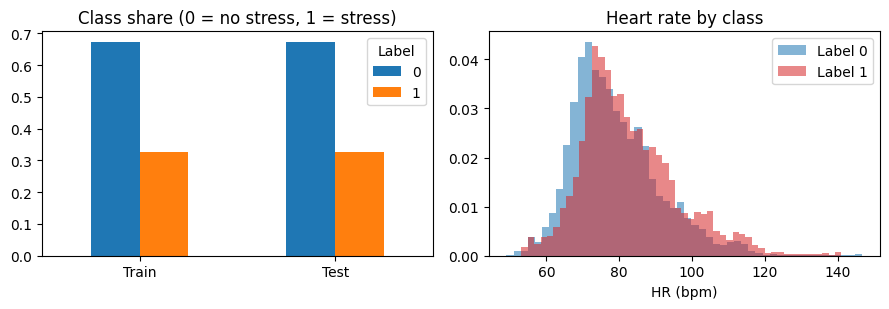

In [10]:
# Split A: stratified random 70/30 split of rows
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, stratify=y, random_state=SEED)
g_train = groups.loc[X_train.index]
print("train rows:", len(X_train), "| test rows:", len(X_test))
print("class share, all  :", (y.value_counts(normalize=True) * 100).round(2).to_dict())
print("class share, train:", (y_train.value_counts(normalize=True) * 100).round(2).to_dict())
print("class share, test :", (y_test.value_counts(normalize=True) * 100).round(2).to_dict())

# Majority-class baseline: always predict "no stress"
baseline = (y_test == 0).mean()
print("majority baseline accuracy:", round(baseline, 3))
print(df.groupby("Label")[FEATURES].mean().round(2))

fig, ax = plt.subplots(1, 2, figsize=(9, 3.2))
pd.DataFrame({"Train": y_train.value_counts(normalize=True),
              "Test": y_test.value_counts(normalize=True)}).T.plot.bar(ax=ax[0], rot=0)
ax[0].set_title("Class share (0 = no stress, 1 = stress)")
for lab, c in [(0, "tab:blue"), (1, "tab:red")]:
    ax[1].hist(df.loc[df.Label == lab, "HR"], bins=50, alpha=.55, color=c, density=True, label=f"Label {lab}")
ax[1].set_title("Heart rate by class"); ax[1].set_xlabel("HR (bpm)"); ax[1].legend()
plt.tight_layout(); plt.show()

# 3. Models and evaluation helpers

In [11]:
def make(model):
    return Pipeline([("scale", StandardScaler()), ("clf", model)])

def evaluate(model, X_, y_, thr=0.5):
    prob = model.predict_proba(X_)[:, 1]
    pred = (prob >= thr).astype(int)
    return {"accuracy": accuracy_score(y_, pred), "precision": precision_score(y_, pred, zero_division=0),
            "recall": recall_score(y_, pred), "f1": f1_score(y_, pred), "auc": roc_auc_score(y_, prob)}

def report(models, Xa, ya, Xb, yb):
    rows = []
    for name, m in models.items():
        rows.append({"model": name, "set": "train", **evaluate(m, Xa, ya)})
        rows.append({"model": name, "set": "test", **evaluate(m, Xb, yb)})
    return pd.DataFrame(rows).round(3)

# Default models
tree = make(DecisionTreeClassifier(random_state=SEED)).fit(X_train, y_train)
forest = make(RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=SEED)).fit(X_train, y_train)
default_models = {"Decision Tree (default)": tree, "Random Forest (default)": forest}
report(default_models, X_train, y_train, X_test, y_test)

,model,set,accuracy,precision,recall,f1,auc
0,Decision Tree (default),train,1.000,1.000,1.000,1.000,1.000
1,Decision Tree (default),test,0.708,0.552,0.565,0.559,0.671
2,Random Forest (default),train,1.000,1.000,1.000,1.000,1.000
3,Random Forest (default),test,0.740,0.623,0.522,0.568,0.782


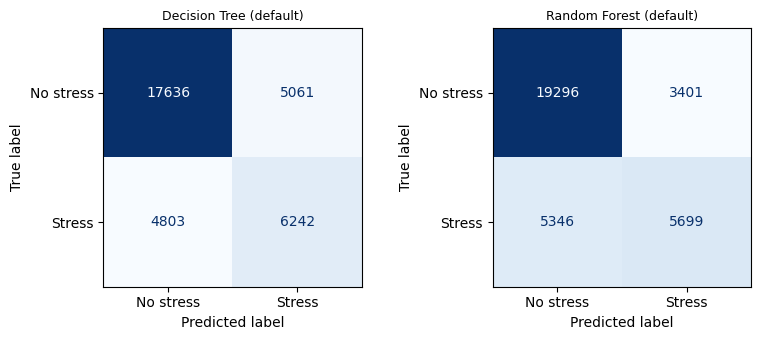

In [12]:
# Confusion matrices on the test set
fig, ax = plt.subplots(1, 2, figsize=(8, 3.5))
for a, (name, m) in zip(ax, default_models.items()):
    ConfusionMatrixDisplay.from_estimator(m, X_test, y_test, ax=a, cmap="Blues", colorbar=False,
                                          display_labels=["No stress", "Stress"])
    a.set_title(name, fontsize=9)
plt.tight_layout(); plt.show()

## 4. Hyperparameter tuning

In [15]:
grids = {
    "Decision Tree": (DecisionTreeClassifier(random_state=SEED),
                      {"clf__max_depth": [3, 5, 8, 12], "clf__min_samples_leaf": [1, 10, 50]}),
    "Random Forest": (RandomForestClassifier(n_estimators=100, random_state=SEED),
                      {"clf__min_samples_leaf": [1, 5, 20], "clf__max_depth": [10, 20]}),
}
tuned_models = {}
for name, (base, grid) in grids.items():
    # Added n_jobs=-1 to parallelize cross-validation across all CPU cores
    gs = GridSearchCV(make(base), grid, scoring="roc_auc", cv=GroupKFold(5), n_jobs=-1)
    gs.fit(X_train, y_train, groups=g_train)
    tuned_models[f"{name} (tuned)"] = gs.best_estimator_
    print(name, "best params:", gs.best_params_, "| grouped-CV AUC:", round(gs.best_score_, 3))

report(tuned_models, X_train, y_train, X_test, y_test)

Decision Tree best params: {'clf__max_depth': 3, 'clf__min_samples_leaf': 1} | grouped-CV AUC: 0.568
Random Forest best params: {'clf__max_depth': 10, 'clf__min_samples_leaf': 1} | grouped-CV AUC: 0.544


,model,set,accuracy,precision,recall,f1,auc
0,Decision Tree (tuned),train,0.680,0.699,0.040,0.076,0.602
1,Decision Tree (tuned),test,0.680,0.702,0.042,0.078,0.602
2,Random Forest (tuned),train,0.715,0.774,0.184,0.297,0.753
3,Random Forest (tuned),test,0.709,0.736,0.171,0.278,0.723


In [16]:
for name, m in tuned_models.items():
    oof = cross_val_predict(m, X_train, y_train, groups=g_train, cv=GroupKFold(5), method="predict_proba")[:, 1]
    thresholds = np.linspace(0.1, 0.9, 81)
    best = thresholds[np.argmax([f1_score(y_train, oof >= t) for t in thresholds])]
    r = evaluate(m, X_test, y_test, best)
    print(name, "| threshold", round(best, 2), "|", {k: round(v, 3) for k, v in r.items()})
print("F1 of an 'always stress' rule:", round(f1_score(y_test, np.ones(len(y_test))), 3))

Decision Tree (tuned) | threshold 0.25 | {'accuracy': 0.45, 'precision': 0.362, 'recall': 0.892, 'f1': 0.515, 'auc': np.float64(0.602)}
Random Forest (tuned) | threshold 0.1 | {'accuracy': 0.367, 'precision': 0.341, 'recall': 0.998, 'f1': 0.508, 'auc': np.float64(0.723)}
F1 of an 'always stress' rule: 0.493


## 5. Generalisation to unseen people

In [17]:
# Split B: 70/30 split by participant
tr_i, te_i = next(GroupShuffleSplit(n_splits=1, test_size=0.30, random_state=SEED).split(X, y, groups))
XB_train, XB_test, yB_train, yB_test = X.iloc[tr_i], X.iloc[te_i], y.iloc[tr_i], y.iloc[te_i]
print("train participants:", groups.iloc[tr_i].nunique(), "| test participants:", groups.iloc[te_i].nunique())
print("majority baseline accuracy:", round((yB_test == 0).mean(), 3))

modelsB = {"Decision Tree (default)": make(DecisionTreeClassifier(random_state=SEED)),
           "Random Forest (default)": make(RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=SEED))}
for m in modelsB.values():
    m.fit(XB_train, yB_train)
report(modelsB, XB_train, yB_train, XB_test, yB_test)

train participants: 23 | test participants: 11
majority baseline accuracy: 0.666


,model,set,accuracy,precision,recall,f1,auc
0,Decision Tree (default),train,1.000,1.000,1.000,1.000,1.000
1,Decision Tree (default),test,0.571,0.349,0.329,0.339,0.511
2,Random Forest (default),train,1.000,1.000,1.000,1.000,1.000
3,Random Forest (default),test,0.599,0.364,0.266,0.307,0.527


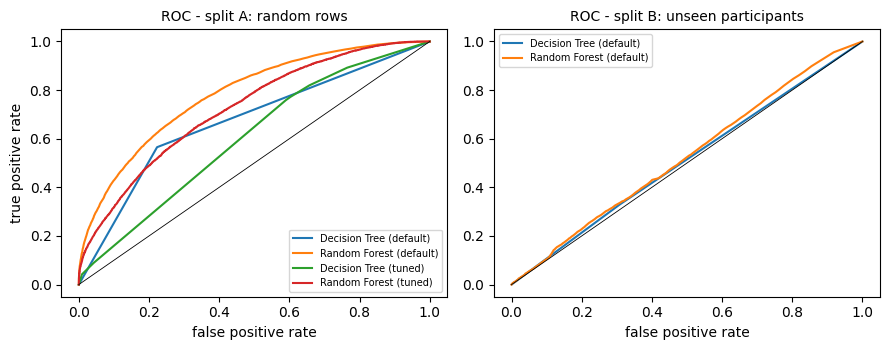

In [18]:
# ROC curves: random split (A) vs unseen participants (B)
fig, ax = plt.subplots(1, 2, figsize=(9, 3.6))
for a, (models, Xb, yb, title) in zip(ax, [({**default_models, **tuned_models}, X_test, y_test, "A: random rows"),
                                           (modelsB, XB_test, yB_test, "B: unseen participants")]):
    for name, m in models.items():
        fpr, tpr, _ = roc_curve(yb, m.predict_proba(Xb)[:, 1])
        a.plot(fpr, tpr, label=name)
    a.plot([0, 1], [0, 1], "k", lw=.6); a.set_title("ROC - split " + title, fontsize=10)
    a.set_xlabel("false positive rate"); a.legend(fontsize=7)
ax[0].set_ylabel("true positive rate")
plt.tight_layout(); plt.show()

In [19]:
# 5-fold cross-validation over all data: random rows vs folds grouped by participant
cv_models = {"Decision Tree (default)": make(DecisionTreeClassifier(random_state=SEED)),
             "Decision Tree (tuned)": tuned_models["Decision Tree (tuned)"],
             "Random Forest (default)": make(RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=SEED)),
             "Random Forest (tuned)": tuned_models["Random Forest (tuned)"]}
schemes = {"random rows": (StratifiedKFold(5, shuffle=True, random_state=SEED), {}),
           "by participant": (GroupKFold(5), {"groups": groups})}
rows = []
for scheme, (cv, kw) in schemes.items():
    for name, m in cv_models.items():
        s = cross_validate(m, X, y, cv=cv, scoring=["accuracy", "f1", "roc_auc"], **kw)
        rows.append({"folds": scheme, "model": name,
                     **{k: f"{s['test_' + k].mean():.3f} +/- {s['test_' + k].std():.3f}" for k in ["accuracy", "f1", "roc_auc"]}})
pd.DataFrame(rows)

,folds,model,accuracy,f1,roc_auc
0,random rows,Decision Tree (default),0.716 +/- 0.002,0.568 +/- 0.005,0.678 +/- 0.003
1,random rows,Decision Tree (tuned),0.676 +/- 0.004,0.039 +/- 0.035,0.607 +/- 0.003
2,random rows,Random Forest (default),0.744 +/- 0.001,0.571 +/- 0.004,0.786 +/- 0.000
3,random rows,Random Forest (tuned),0.708 +/- 0.002,0.283 +/- 0.010,0.725 +/- 0.003
4,by participant,Decision Tree (default),0.573 +/- 0.021,0.348 +/- 0.021,0.515 +/- 0.019
5,by participant,Decision Tree (tuned),0.665 +/- 0.008,0.028 +/- 0.046,0.564 +/- 0.042
6,by participant,Random Forest (default),0.595 +/- 0.026,0.322 +/- 0.025,0.531 +/- 0.035
7,by participant,Random Forest (tuned),0.659 +/- 0.019,0.191 +/- 0.066,0.561 +/- 0.044


In [20]:
# Random Forest feature importance (default model, split A)
imp = forest.named_steps["clf"].feature_importances_
print(dict(zip(FEATURES, imp.round(3))))

{'HR': np.float64(0.411), 'respr': np.float64(0.589)}
